# END-TO-END REGRESSION PIPELINE FOR SONG YEAR PREDICTION

In [2]:
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
import gc
warnings.filterwarnings('ignore')
np.random.seed(42)
print("\n✓ All libraries imported successfully!")


✓ All libraries imported successfully!


# Data Load

In [3]:
file_id = '1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'midterm-regresi-dataset.csv'
gdown.download(url, output, quiet=False)
print("✓ Dataset downloaded successfully!")
print("Reading Dataset...")
df = pd.read_csv('midterm-regresi-dataset.csv', header=None, dtype=np.float32)
print("✓ Dataset read successfully!")

# Assign column names
num_features = df.shape[1] - 1
cols = ['year'] + [f'feature_{i}' for i in range(1, num_features + 1)]
df.columns = cols

print(f"\n{'─'*50}")
print("OUTPUT: DATA LOADING RESULTS")
print(f"{'─'*50}")
print(f"• Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"• Number of Features: {num_features}")
print(f"• Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n• First 5 Rows Preview:")
print(df.head())
print(f"\n• Data Types: {df.dtypes.unique()}")

Downloading...
From (original): https://drive.google.com/uc?id=1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9
From (redirected): https://drive.google.com/uc?id=1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9&confirm=t&uuid=ebb6accd-efcf-48a3-9614-bdfe2ff677a2
To: /content/midterm-regresi-dataset.csv
100%|██████████| 443M/443M [00:11<00:00, 37.3MB/s]


✓ Dataset downloaded successfully!
Reading Dataset...
✓ Dataset read successfully!

──────────────────────────────────────────────────
OUTPUT: DATA LOADING RESULTS
──────────────────────────────────────────────────
• Dataset Shape: 515,345 rows × 91 columns
• Number of Features: 90
• Memory Usage: 178.90 MB

• First 5 Rows Preview:
     year  feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0  2001.0  49.943569   21.47114  73.077499    8.74861 -17.406281 -13.099050   
1  2001.0  48.732151   18.42930  70.326790   12.94636 -10.324370 -24.837770   
2  2001.0  50.957142   31.85602  55.818508   13.41693  -6.578980 -18.549400   
3  2001.0  48.247501   -1.89837  36.297722    2.58776   0.971700 -26.216829   
4  2001.0  50.970200   42.20998  67.099640    8.46791 -15.852790 -16.814091   

   feature_7  feature_8  feature_9  ...  feature_81  feature_82  feature_83  \
0  -25.01202  -12.23257   7.830890  ...   13.016200  -54.405479   58.993671   
1    8.76630   -0.92019  18.76548

# Data Exploration


──────────────────────────────────────────────────
OUTPUT 2.1: TARGET VARIABLE (Year) STATISTICS
──────────────────────────────────────────────────
count    515345.000000
mean       1998.396851
std          12.595524
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2011.000000
Name: year, dtype: float64

• Year Range: 1922 - 2011
• Total Unique Years: 89
• Most Common Year: 2007

──────────────────────────────────────────────────
OUTPUT 2.2: FEATURE STATISTICS (Sample)
──────────────────────────────────────────────────
         feature_1    feature_2    feature_3    feature_4    feature_5
count  515345.0000  515345.0000  515345.0000  515345.0000  515345.0000
mean       43.3871       1.2896       8.6583       1.1641      -6.5536
std         6.0670      51.5748      35.2646      16.3212      22.8588
min         1.7490    -337.0925    -301.0051    -154.1836    -181.9534
25%        39.9547     -26.0595     -11.4627      -8.4875     -20

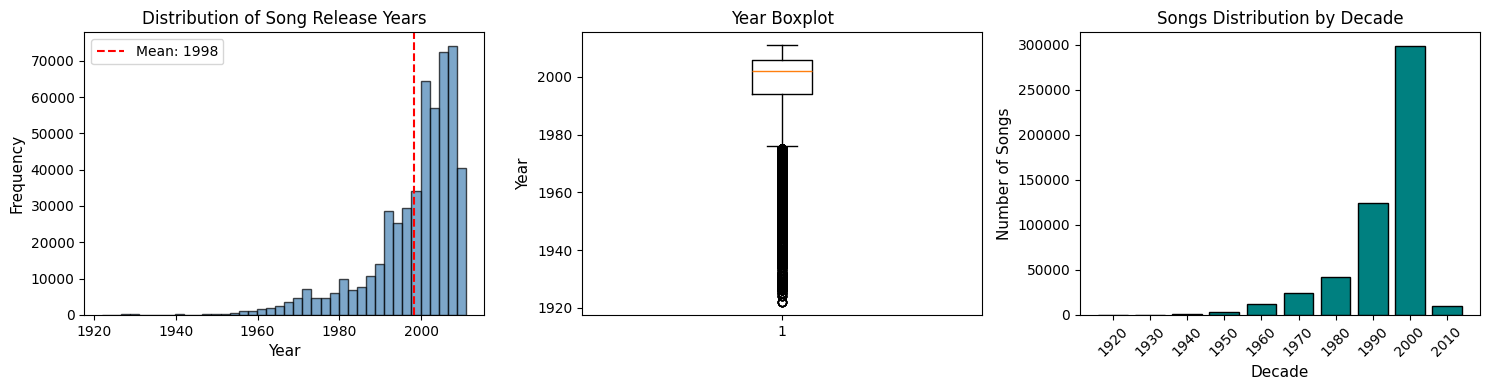

✓ Figure saved: 'part2_exploration.png'


In [4]:
# 2.1 Target Variable Analysis
print(f"\n{'─'*50}")
print("OUTPUT 2.1: TARGET VARIABLE (Year) STATISTICS")
print(f"{'─'*50}")
target_stats = df['year'].describe()
print(target_stats)
print(f"\n• Year Range: {int(df['year'].min())} - {int(df['year'].max())}")
print(f"• Total Unique Years: {df['year'].nunique()}")
print(f"• Most Common Year: {int(df['year'].mode()[0])}")

# 2.2 Feature Statistics
print(f"\n{'─'*50}")
print("OUTPUT 2.2: FEATURE STATISTICS (Sample)")
print(f"{'─'*50}")
sample_features = [f'feature_{i}' for i in range(1, 6)]
print(df[sample_features].describe().round(4))

# 2.3 Visualization
print(f"\n{'─'*50}")
print("OUTPUT 2.3: VISUALIZATIONS")
print(f"{'─'*50}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['year'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Song Release Years', fontsize=12)
axes[0].axvline(df['year'].mean(), color='red', linestyle='--', label=f'Mean: {df["year"].mean():.0f}')
axes[0].legend()

axes[1].boxplot(df['year'], vert=True)
axes[1].set_ylabel('Year', fontsize=11)
axes[1].set_title('Year Boxplot', fontsize=12)

df['decade'] = (df['year'] // 10 * 10).astype(int)
decade_counts = df['decade'].value_counts().sort_index()
axes[2].bar(decade_counts.index.astype(str), decade_counts.values, color='teal', edgecolor='black')
axes[2].set_xlabel('Decade', fontsize=11)
axes[2].set_ylabel('Number of Songs', fontsize=11)
axes[2].set_title('Songs Distribution by Decade', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('part2_exploration.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure saved: 'part2_exploration.png'")

# Data Cleaning

In [5]:
# 3.1 Missing Values
print(f"\n{'─'*50}")
print("OUTPUT 3.1: MISSING VALUES CHECK")
print(f"{'─'*50}")
missing_total = df.isnull().sum().sum()
missing_per_col = df.isnull().sum()
cols_with_missing = missing_per_col[missing_per_col > 0]

print(f"• Total Missing Values: {missing_total}")
print(f"• Columns with Missing Values: {len(cols_with_missing)}")
if len(cols_with_missing) > 0:
    print(cols_with_missing)
    df = df.fillna(df.median())
    print("✓ Action: Missing values filled with column median")
else:
    print("✓ Status: Dataset is complete - no missing values!")

# 3.2 Duplicates
print(f"\n{'─'*50}")
print("OUTPUT 3.2: DUPLICATE ROWS CHECK")
print(f"{'─'*50}")
duplicates = df.duplicated().sum()
print(f"• Duplicate Rows Found: {duplicates}")
if duplicates > 0:
    df_before = len(df)
    df = df.drop_duplicates()
    print(f"✓ Action: Removed {duplicates} duplicates")
    print(f"• Shape Before: {df_before} rows")
    print(f"• Shape After: {len(df)} rows")
else:
    print("✓ Status: No duplicate rows found!")

# 3.3 Infinite Values
print(f"\n{'─'*50}")
print("OUTPUT 3.3: INFINITE VALUES CHECK")
print(f"{'─'*50}")
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print(f"• Infinite Values Found: {inf_count}")
if inf_count > 0:
    df = df.replace([np.inf, -np.inf], np.nan).fillna(df.median())
    print("✓ Action: Infinite values replaced with median")
else:
    print("✓ Status: No infinite values found!")

# Summary
print(f"\n{'─'*50}")
print("OUTPUT 3.4: CLEANING SUMMARY")
print(f"{'─'*50}")
print(f"• Final Dataset Shape: {df.shape}")
print(f"• Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



──────────────────────────────────────────────────
OUTPUT 3.1: MISSING VALUES CHECK
──────────────────────────────────────────────────
• Total Missing Values: 0
• Columns with Missing Values: 0
✓ Status: Dataset is complete - no missing values!

──────────────────────────────────────────────────
OUTPUT 3.2: DUPLICATE ROWS CHECK
──────────────────────────────────────────────────
• Duplicate Rows Found: 214
✓ Action: Removed 214 duplicates
• Shape Before: 515345 rows
• Shape After: 515131 rows

──────────────────────────────────────────────────
OUTPUT 3.3: INFINITE VALUES CHECK
──────────────────────────────────────────────────
• Infinite Values Found: 0
✓ Status: No infinite values found!

──────────────────────────────────────────────────
OUTPUT 3.4: CLEANING SUMMARY
──────────────────────────────────────────────────
• Final Dataset Shape: (515131, 92)
• Memory Usage: 186.68 MB


# Outlier Detection and Handling

In [6]:
def detect_outliers_iqr(series, threshold=1.5):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - threshold * IQR, Q3 + threshold * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    pct = outliers / len(series) * 100
    return outliers, pct, lower, upper

# 4.1 Outlier Detection
print(f"\n{'─'*50}")
print("OUTPUT 4.1: OUTLIER DETECTION (IQR Method, threshold=1.5)")
print(f"{'─'*50}")
print(f"{'Column':<15} {'Outliers':>10} {'Percent':>10} {'Lower':>12} {'Upper':>12}")
print("─" * 60)

feature_cols = [c for c in df.columns if c.startswith('feature_')]
outlier_data = []

for col in ['year'] + feature_cols[:8]:
    n_out, pct, lower, upper = detect_outliers_iqr(df[col])
    outlier_data.append({'col': col, 'n': n_out, 'pct': pct})
    print(f"{col:<15} {n_out:>10,} {pct:>9.2f}% {lower:>12.2f} {upper:>12.2f}")

print("... (showing first 8 features)")

# 4.2 Outlier Handling
print(f"\n{'─'*50}")
print("OUTPUT 4.2: OUTLIER HANDLING")
print(f"{'─'*50}")
print("Method: Clipping values to 1st-99th percentile range")

# Store original stats for comparison
orig_stats = df[feature_cols[:3]].describe().loc[['min', 'max']]

for col in feature_cols:
    p1, p99 = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(p1, p99)

new_stats = df[feature_cols[:3]].describe().loc[['min', 'max']]

print(f"\n• Features Processed: {len(feature_cols)}")
print("\nBefore vs After Clipping (Sample Features):")
print("\nBEFORE:")
print(orig_stats)
print("\nAFTER:")
print(new_stats)
print("\n✓ Outlier handling complete!")
gc.collect()


──────────────────────────────────────────────────
OUTPUT 4.1: OUTLIER DETECTION (IQR Method, threshold=1.5)
──────────────────────────────────────────────────
Column            Outliers    Percent        Lower        Upper
────────────────────────────────────────────────────────────
year                29,695      5.76%      1976.00      2024.00
feature_1           10,620      2.06%        28.13        59.65
feature_2           14,641      2.84%      -119.35       129.40
feature_3           15,625      3.03%       -73.31        91.61
feature_4           22,677      4.40%       -34.40        34.70
feature_5           10,454      2.03%       -63.28        50.35
feature_6           11,987      2.33%       -42.52        21.69
feature_7           13,902      2.70%       -36.71        32.44
feature_8           14,532      2.82%       -20.54        16.99
... (showing first 8 features)

──────────────────────────────────────────────────
OUTPUT 4.2: OUTLIER HANDLING
──────────────────────────

9

# Feature Engineering and Selection


──────────────────────────────────────────────────
OUTPUT 5.1: FEATURE-TARGET SEPARATION
──────────────────────────────────────────────────
• Features Matrix (X): (515131, 91)
• Target Vector (y): (515131,)

──────────────────────────────────────────────────
OUTPUT 5.2: CORRELATION WITH TARGET
──────────────────────────────────────────────────

Top 15 Most Correlated Features with Year:
─────────────────────────────────────────────
Rank   Feature                Correlation
─────────────────────────────────────────────
1      decade                   0.9666  ████████████████████████████
2      feature_1                0.2289  ██████
3      feature_6                0.1912  █████
4      feature_3                0.1426  ████
5      feature_63               0.1340  ████
6      feature_40               0.1335  ████
7      feature_7                0.1120  ███
8      feature_69               0.1111  ███
9      feature_46               0.1088  ███
10     feature_67               0.1076  ███
11

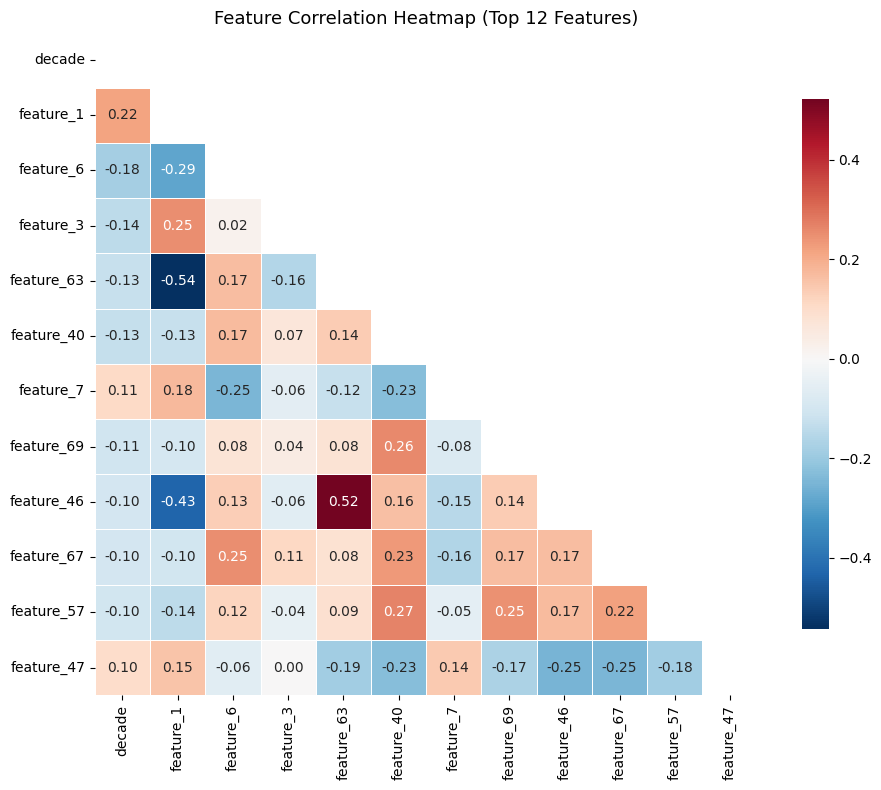

✓ Figure saved: 'part5_correlation.png'


9747

In [7]:
# 5.1 Separate Features and Target
X = df.drop('year', axis=1)
y = df['year']

print(f"\n{'─'*50}")
print("OUTPUT 5.1: FEATURE-TARGET SEPARATION")
print(f"{'─'*50}")
print(f"• Features Matrix (X): {X.shape}")
print(f"• Target Vector (y): {y.shape}")

# 5.2 Correlation Analysis
print(f"\n{'─'*50}")
print("OUTPUT 5.2: CORRELATION WITH TARGET")
print(f"{'─'*50}")

correlations = X.corrwith(y).abs().sort_values(ascending=False)

print("\nTop 15 Most Correlated Features with Year:")
print("─" * 45)
print(f"{'Rank':<6} {'Feature':<18} {'Correlation':>15}")
print("─" * 45)
for i, (feat, corr) in enumerate(correlations.head(15).items(), 1):
    bar = '█' * int(corr * 30)
    print(f"{i:<6} {feat:<18} {corr:>12.4f}  {bar}")

print("\n\nBottom 5 Least Correlated Features:")
print("─" * 45)
for feat, corr in correlations.tail(5).items():
    print(f"       {feat:<18} {corr:>12.4f}")

# Correlation statistics
print(f"\n• Mean Correlation: {correlations.mean():.4f}")
print(f"• Max Correlation: {correlations.max():.4f}")
print(f"• Min Correlation: {correlations.min():.4f}")

# 5.3 Feature Selection
print(f"\n{'─'*50}")
print("OUTPUT 5.3: FEATURE SELECTION")
print(f"{'─'*50}")

corr_threshold = 0.02
high_corr = correlations[correlations > corr_threshold]
low_corr = correlations[correlations <= corr_threshold]

print(f"• Correlation Threshold: > {corr_threshold}")
print(f"• Features Above Threshold: {len(high_corr)}")
print(f"• Features Below Threshold (Removed): {len(low_corr)}")

if len(low_corr) > 0:
    print(f"• Removed Features: {list(low_corr.index)}")

X = X[high_corr.index.tolist()]
selected_features = X.columns.tolist()
print(f"\n✓ Final Selected Features: {len(selected_features)}")

# 5.4 Correlation Heatmap
print(f"\n{'─'*50}")
print("OUTPUT 5.4: FEATURE CORRELATION HEATMAP")
print(f"{'─'*50}")

top_n = min(12, len(selected_features))
top_feats = correlations.head(top_n).index.tolist()

plt.figure(figsize=(10, 8))
corr_matrix = X[top_feats].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title(f'Feature Correlation Heatmap (Top {top_n} Features)', fontsize=13)
plt.tight_layout()
plt.savefig('part5_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure saved: 'part5_correlation.png'")

del df
gc.collect()

# Data Pre-Processing

In [8]:
# 6.1 Train-Test Split
print(f"\n{'─'*50}")
print("OUTPUT 6.1: TRAIN-TEST SPLIT (80-20)")
print(f"{'─'*50}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"• Total Samples: {len(X):,}")
print(f"• Training Set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"• Test Set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n• X_train Shape: {X_train.shape}")
print(f"• X_test Shape: {X_test.shape}")
print(f"• y_train Shape: {y_train.shape}")
print(f"• y_test Shape: {y_test.shape}")

# 6.2 Feature Scaling
print(f"\n{'─'*50}")
print("OUTPUT 6.2: FEATURE SCALING (StandardScaler)")
print(f"{'─'*50}")

print("\nBEFORE Scaling (First 3 Features):")
print(f"  Mean: [{X_train.iloc[:, 0].mean():.4f}, {X_train.iloc[:, 1].mean():.4f}, {X_train.iloc[:, 2].mean():.4f}]")
print(f"  Std:  [{X_train.iloc[:, 0].std():.4f}, {X_train.iloc[:, 1].std():.4f}, {X_train.iloc[:, 2].std():.4f}]")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("\nAFTER Scaling (First 3 Features):")
print(f"  Mean: [{X_train_scaled[:, 0].mean():.4f}, {X_train_scaled[:, 1].mean():.4f}, {X_train_scaled[:, 2].mean():.4f}]")
print(f"  Std:  [{X_train_scaled[:, 0].std():.4f}, {X_train_scaled[:, 1].std():.4f}, {X_train_scaled[:, 2].std():.4f}]")

y_train_np = y_train.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)

print("\n✓ Scaling complete - features now have mean≈0 and std≈1")

del X, y, X_train, X_test
gc.collect()


──────────────────────────────────────────────────
OUTPUT 6.1: TRAIN-TEST SPLIT (80-20)
──────────────────────────────────────────────────
• Total Samples: 515,131
• Training Set: 412,104 samples (80%)
• Test Set: 103,027 samples (20%)

• X_train Shape: (412104, 69)
• X_test Shape: (103027, 69)
• y_train Shape: (412104,)
• y_test Shape: (103027,)

──────────────────────────────────────────────────
OUTPUT 6.2: FEATURE SCALING (StandardScaler)
──────────────────────────────────────────────────

BEFORE Scaling (First 3 Features):
  Mean: [1993.3656, 43.4147, -9.5544]
  Std:  [10.8353, 5.9325, 12.4038]

AFTER Scaling (First 3 Features):
  Mean: [-0.0000, -0.0000, -0.0000]
  Std:  [1.0000, 1.0000, 1.0000]

✓ Scaling complete - features now have mean≈0 and std≈1


0

# MODEL TRAINING & HYPERPARAMETER TUNING


In [9]:
results = []
predictions = {}
models = {}

In [10]:
# --- Model 1: Ridge Regression ---
print(f"\n{'─'*50}")
print("MODEL 7.1: RIDGE REGRESSION")
print(f"{'─'*50}")

alphas = [0.1, 1.0, 10.0, 100.0]
print("\nHyperparameter Tuning (2-Fold Cross-Validation):")
print(f"{'Alpha':<12} {'Mean RMSE':<15} {'Std RMSE':<15} {'Status'}")
print("─" * 55)

best_ridge_score, best_ridge_alpha = -np.inf, 1.0

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    scores = cross_val_score(ridge, X_train_scaled, y_train_np, cv=2, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores)
    status = ""
    if scores.mean() > best_ridge_score:
        best_ridge_score = scores.mean()
        best_ridge_alpha = alpha
        status = "← Best"
    print(f"{alpha:<12} {rmse.mean():<15.4f} {rmse.std():<15.4f} {status}")

print(f"\n✓ Best Alpha: {best_ridge_alpha}")

ridge_model = Ridge(alpha=best_ridge_alpha, random_state=42)
ridge_model.fit(X_train_scaled, y_train_np)
predictions['Ridge'] = ridge_model.predict(X_test_scaled)
models['Ridge'] = ridge_model
print(f"✓ Model trained on full training set")



──────────────────────────────────────────────────
MODEL 7.1: RIDGE REGRESSION
──────────────────────────────────────────────────

Hyperparameter Tuning (2-Fold Cross-Validation):
Alpha        Mean RMSE       Std RMSE        Status
───────────────────────────────────────────────────────
0.1          2.7589          0.0002          ← Best
1.0          2.7589          0.0002          ← Best
10.0         2.7589          0.0002          
100.0        2.7589          0.0002          

✓ Best Alpha: 1.0
✓ Model trained on full training set


In [11]:
# --- Model 2: Lasso Regression ---
print(f"\n{'─'*50}")
print("MODEL 7.2: LASSO REGRESSION")
print(f"{'─'*50}")

alphas = [0.001, 0.01, 0.1, 1.0]
print("\nHyperparameter Tuning (2-Fold Cross-Validation):")
print(f"{'Alpha':<12} {'Mean RMSE':<15} {'Std RMSE':<15} {'Status'}")
print("─" * 55)

best_lasso_score, best_lasso_alpha = -np.inf, 0.1

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=2000)
    scores = cross_val_score(lasso, X_train_scaled, y_train_np, cv=2, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores)
    status = ""
    if scores.mean() > best_lasso_score:
        best_lasso_score = scores.mean()
        best_lasso_alpha = alpha
        status = "← Best"
    print(f"{alpha:<12} {rmse.mean():<15.4f} {rmse.std():<15.4f} {status}")

print(f"\n✓ Best Alpha: {best_lasso_alpha}")

lasso_model = Lasso(alpha=best_lasso_alpha, random_state=42, max_iter=2000)
lasso_model.fit(X_train_scaled, y_train_np)
predictions['Lasso'] = lasso_model.predict(X_test_scaled)
models['Lasso'] = lasso_model

# Non-zero coefficients
n_nonzero = np.sum(lasso_model.coef_ != 0)
print(f"✓ Non-zero Coefficients: {n_nonzero}/{len(lasso_model.coef_)} (Lasso feature selection)")


──────────────────────────────────────────────────
MODEL 7.2: LASSO REGRESSION
──────────────────────────────────────────────────

Hyperparameter Tuning (2-Fold Cross-Validation):
Alpha        Mean RMSE       Std RMSE        Status
───────────────────────────────────────────────────────
0.001        2.7589          0.0002          ← Best
0.01         2.7603          0.0004          
0.1          2.7909          0.0001          
1.0          2.9773          0.0011          

✓ Best Alpha: 0.001
✓ Non-zero Coefficients: 67/69 (Lasso feature selection)


In [12]:
start_time = datetime.now()
# --- Model 3: Random Forest ---
print(f"\n{'─'*50}")
print("MODEL 7.3: RANDOM FOREST REGRESSOR")
print(f"{'─'*50}")

print("\nConfiguration (Memory-Efficient):")
rf_params = {
    'n_estimators': 50,
    'max_depth': 10,
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1
}
for k, v in rf_params.items():
    print(f"  • {k}: {v}")

rf_model = RandomForestRegressor(**rf_params)
rf_model.fit(X_train_scaled, y_train_np)
predictions['Random Forest'] = rf_model.predict(X_test_scaled)
models['Random Forest'] = rf_model
print(f"\n✓ Training complete!")
end_time = datetime.now()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time}")


──────────────────────────────────────────────────
MODEL 7.3: RANDOM FOREST REGRESSOR
──────────────────────────────────────────────────

Configuration (Memory-Efficient):
  • n_estimators: 50
  • max_depth: 10
  • min_samples_split: 10
  • min_samples_leaf: 5
  • max_features: sqrt
  • random_state: 42
  • n_jobs: -1

✓ Training complete!
Elapsed time: 0:03:59.558046


In [13]:
start_time = datetime.now()
# --- Model 4: Gradient Boosting ---
print(f"\n{'─'*50}")
print("MODEL 7.4: GRADIENT BOOSTING REGRESSOR")
print(f"{'─'*50}")

print("\nConfiguration (Memory-Efficient):")
gb_params = {
    'n_estimators': 30,
    'max_depth': 5,
    'learning_rate': 0.1,
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'subsample': 0.8,
    'random_state': 42
}
for k, v in gb_params.items():
    print(f"  • {k}: {v}")

gb_model = GradientBoostingRegressor(**gb_params)
gb_model.fit(X_train_scaled, y_train_np)
predictions['Gradient Boosting'] = gb_model.predict(X_test_scaled)
models['Gradient Boosting'] = gb_model
print(f"\n✓ Training complete!")
end_time = datetime.now()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time}")


──────────────────────────────────────────────────
MODEL 7.4: GRADIENT BOOSTING REGRESSOR
──────────────────────────────────────────────────

Configuration (Memory-Efficient):
  • n_estimators: 30
  • max_depth: 5
  • learning_rate: 0.1
  • min_samples_split: 10
  • min_samples_leaf: 5
  • subsample: 0.8
  • random_state: 42

✓ Training complete!
Elapsed time: 0:19:36.835770


In [14]:
gc.collect()

71

# Model Evaluation


──────────────────────────────────────────────────
OUTPUT 8.1: REGRESSION METRICS COMPARISON
──────────────────────────────────────────────────

            Model       MSE     RMSE      MAE       R2
Gradient Boosting  7.154716 2.674830 2.255939 0.939205
            Lasso  7.570310 2.751420 2.343823 0.935673
            Ridge  7.570529 2.751459 2.343554 0.935671
    Random Forest 21.666595 4.654739 3.490626 0.815893

──────────────────────────────────────────────────
★ BEST MODEL: Gradient Boosting
──────────────────────────────────────────────────
  • RMSE: 2.6748 years
  • MAE:  2.2559 years
  • R²:   0.9392 (93.92% variance explained)

──────────────────────────────────────────────────
OUTPUT 8.2: EVALUATION VISUALIZATIONS
──────────────────────────────────────────────────


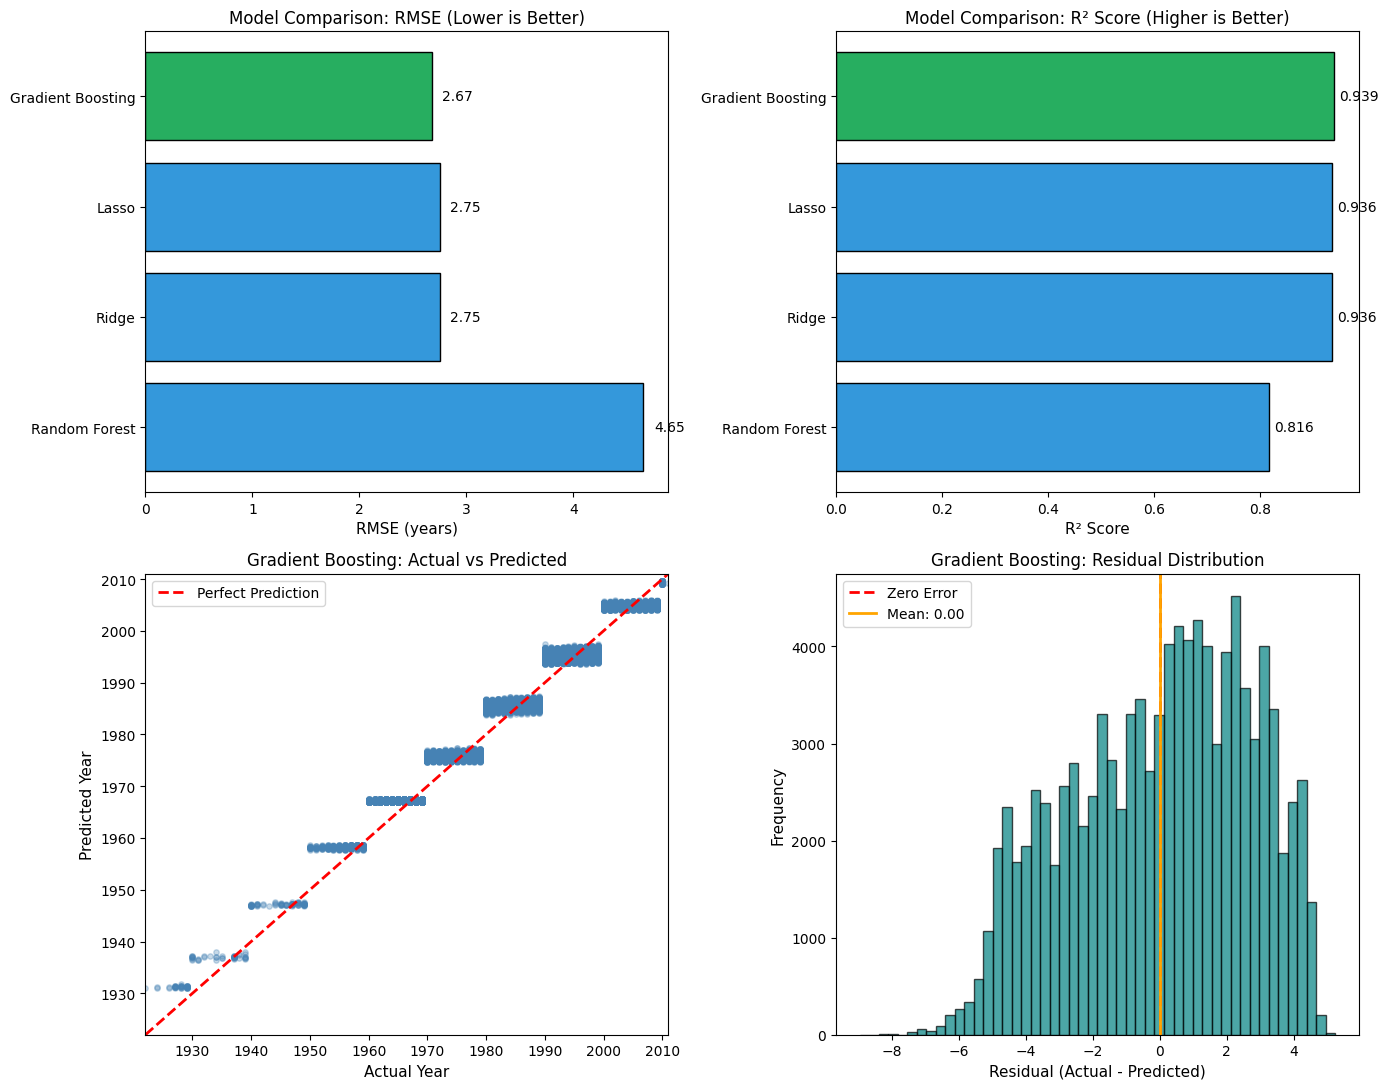

✓ Figure saved: 'part8_evaluation.png'


In [15]:
def calc_metrics(y_true, y_pred):
    return {
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

# Calculate metrics for all models
print(f"\n{'─'*50}")
print("OUTPUT 8.1: REGRESSION METRICS COMPARISON")
print(f"{'─'*50}")

for name, preds in predictions.items():
    metrics = calc_metrics(y_test_np, preds)
    results.append({'Model': name, **metrics})

results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n" + results_df.to_string(index=False))

# Best model
best = results_df.iloc[0]
print(f"\n{'─'*50}")
print(f"★ BEST MODEL: {best['Model']}")
print(f"{'─'*50}")
print(f"  • RMSE: {best['RMSE']:.4f} years")
print(f"  • MAE:  {best['MAE']:.4f} years")
print(f"  • R²:   {best['R2']:.4f} ({best['R2']*100:.2f}% variance explained)")

# Visualization
print(f"\n{'─'*50}")
print("OUTPUT 8.2: EVALUATION VISUALIZATIONS")
print(f"{'─'*50}")

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Plot 1: RMSE Comparison
ax1 = axes[0, 0]
colors = ['#27ae60' if m == best['Model'] else '#3498db' for m in results_df['Model']]
bars = ax1.barh(results_df['Model'], results_df['RMSE'], color=colors, edgecolor='black')
ax1.set_xlabel('RMSE (years)', fontsize=11)
ax1.set_title('Model Comparison: RMSE (Lower is Better)', fontsize=12)
ax1.invert_yaxis()
for bar, val in zip(bars, results_df['RMSE']):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)

# Plot 2: R² Comparison
ax2 = axes[0, 1]
bars = ax2.barh(results_df['Model'], results_df['R2'], color=colors, edgecolor='black')
ax2.set_xlabel('R² Score', fontsize=11)
ax2.set_title('Model Comparison: R² Score (Higher is Better)', fontsize=12)
ax2.invert_yaxis()
for bar, val in zip(bars, results_df['R2']):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)

# Plot 3: Actual vs Predicted
ax3 = axes[1, 0]
best_preds = predictions[best['Model']]
ax3.scatter(y_test_np, best_preds, alpha=0.3, s=15, c='steelblue')
lims = [min(y_test_np.min(), best_preds.min()), max(y_test_np.max(), best_preds.max())]
ax3.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Year', fontsize=11)
ax3.set_ylabel('Predicted Year', fontsize=11)
ax3.set_title(f'{best["Model"]}: Actual vs Predicted', fontsize=12)
ax3.legend(loc='upper left')
ax3.set_xlim(lims)
ax3.set_ylim(lims)

# Plot 4: Residuals
ax4 = axes[1, 1]
residuals = y_test_np - best_preds
ax4.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='teal')
ax4.axvline(x=0, color='red', linestyle='--', lw=2, label='Zero Error')
ax4.axvline(x=residuals.mean(), color='orange', linestyle='-', lw=2, label=f'Mean: {residuals.mean():.2f}')
ax4.set_xlabel('Residual (Actual - Predicted)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title(f'{best["Model"]}: Residual Distribution', fontsize=12)
ax4.legend()

plt.tight_layout()
plt.savefig('part8_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure saved: 'part8_evaluation.png'")

# Feature Importance Analysis


Top 15 Most Important Features:
──────────────────────────────────────────────────
Rank   Feature              Importance
──────────────────────────────────────────────────
1      decade                   0.7939  ███████████████████████████████████████████████████████████████████████████████
2      feature_1                0.0498  ████
3      feature_6                0.0165  █
4      feature_3                0.0148  █
5      feature_2                0.0082  
6      feature_20               0.0082  
7      feature_14               0.0080  
8      feature_63               0.0075  
9      feature_22               0.0044  
10     feature_46               0.0044  
11     feature_73               0.0041  
12     feature_36               0.0039  
13     feature_40               0.0035  
14     feature_41               0.0033  
15     feature_7                0.0033  

──────────────────────────────────────────────────
OUTPUT 9.2: GRADIENT BOOSTING FEATURE IMPORTANCE
─────────────────────────

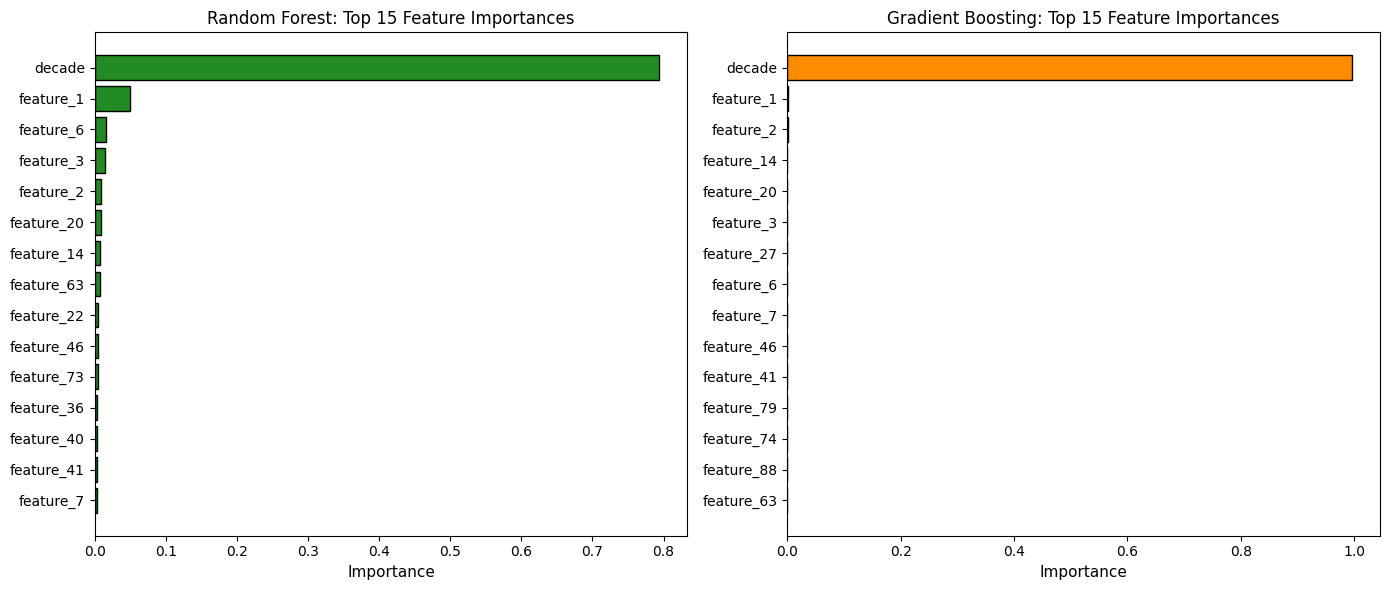

✓ Figure saved: 'part9_feature_importance.png'

──────────────────────────────────────────────────
OUTPUT 9.4: TOP 5 FEATURES COMPARISON ACROSS MODELS
──────────────────────────────────────────────────

Random Forest             Gradient Boosting        
──────────────────────────────────────────────────
decade                    decade                   
feature_1                 feature_1                
feature_6                 feature_2                
feature_3                 feature_14               
feature_2                 feature_20               


In [16]:
rf_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print("─" * 50)
print(f"{'Rank':<6} {'Feature':<18} {'Importance':>12}")
print("─" * 50)
for i, (_, row) in enumerate(rf_importance.head(15).iterrows(), 1):
    bar = '█' * int(row['Importance'] * 100)
    print(f"{i:<6} {row['Feature']:<18} {row['Importance']:>12.4f}  {bar}")

# Gradient Boosting Feature Importance
print(f"\n{'─'*50}")
print("OUTPUT 9.2: GRADIENT BOOSTING FEATURE IMPORTANCE")
print(f"{'─'*50}")

gb_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features:")
print("─" * 50)
print(f"{'Rank':<6} {'Feature':<18} {'Importance':>12}")
print("─" * 50)
for i, (_, row) in enumerate(gb_importance.head(15).iterrows(), 1):
    bar = '█' * int(row['Importance'] * 100)
    print(f"{i:<6} {row['Feature']:<18} {row['Importance']:>12.4f}  {bar}")

# Visualization
print(f"\n{'─'*50}")
print("OUTPUT 9.3: FEATURE IMPORTANCE VISUALIZATION")
print(f"{'─'*50}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
top_rf = rf_importance.head(15)
axes[0].barh(range(len(top_rf)), top_rf['Importance'].values, color='forestgreen', edgecolor='black')
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf['Feature'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title('Random Forest: Top 15 Feature Importances', fontsize=12)

# Gradient Boosting
top_gb = gb_importance.head(15)
axes[1].barh(range(len(top_gb)), top_gb['Importance'].values, color='darkorange', edgecolor='black')
axes[1].set_yticks(range(len(top_gb)))
axes[1].set_yticklabels(top_gb['Feature'].values)
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title('Gradient Boosting: Top 15 Feature Importances', fontsize=12)

plt.tight_layout()
plt.savefig('part9_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure saved: 'part9_feature_importance.png'")

# Compare top features across models
print(f"\n{'─'*50}")
print("OUTPUT 9.4: TOP 5 FEATURES COMPARISON ACROSS MODELS")
print(f"{'─'*50}")
print(f"\n{'Random Forest':<25} {'Gradient Boosting':<25}")
print("─" * 50)
for i in range(5):
    rf_feat = rf_importance.iloc[i]['Feature']
    gb_feat = gb_importance.iloc[i]['Feature']
    print(f"{rf_feat:<25} {gb_feat:<25}")

# Result and Summary

In [17]:
print(f"""
{'─'*60}
EXECUTIVE SUMMARY
{'─'*60}

1. DATASET OVERVIEW
   • Total Samples: {len(y_train_np) + len(y_test_np):,}
   • Number of Features: {len(selected_features)}
   • Target Variable: Song Release Year
   • Year Range: {int(y_test_np.min())} - {int(y_test_np.max())}

2. BEST MODEL PERFORMANCE
   ┌────────────────────────────────────────┐
   │  Model: {best['Model']:<28} │
   │  RMSE:  {best['RMSE']:.4f} years{' '*19}│
   │  MAE:   {best['MAE']:.4f} years{' '*19}│
   │  R²:    {best['R2']:.4f} ({best['R2']*100:.2f}% variance){' '*6}│
   └────────────────────────────────────────┘

3. INTERPRETATION OF METRICS
   • RMSE ({best['RMSE']:.2f} years): On average, predictions deviate
     by approximately {best['RMSE']:.1f} years from actual release year.

   • MAE ({best['MAE']:.2f} years): The typical prediction error is
     about {best['MAE']:.1f} years - half of errors are smaller than this.

   • R² ({best['R2']:.4f}): The model explains {best['R2']*100:.1f}% of the
     variance in song release years based on audio features.

4. MODEL RANKING (by RMSE)
""")

for i, (_, row) in enumerate(results_df.iterrows(), 1):
    marker = "★" if i == 1 else " "
    print(f"   {marker} {i}. {row['Model']:<20} RMSE: {row['RMSE']:.4f}  R²: {row['R2']:.4f}")


# Final Summary Table
print(f"{'─'*50}")
print("FINAL METRICS TABLE")
print(f"{'─'*50}")
print(results_df.to_string(index=False))

# Memory cleanup
gc.collect()



────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
────────────────────────────────────────────────────────────

1. DATASET OVERVIEW
   • Total Samples: 515,131
   • Number of Features: 69
   • Target Variable: Song Release Year
   • Year Range: 1922 - 2011

2. BEST MODEL PERFORMANCE
   ┌────────────────────────────────────────┐
   │  Model: Gradient Boosting            │
   │  RMSE:  2.6748 years                   │
   │  MAE:   2.2559 years                   │
   │  R²:    0.9392 (93.92% variance)      │
   └────────────────────────────────────────┘

3. INTERPRETATION OF METRICS
   • RMSE (2.67 years): On average, predictions deviate
     by approximately 2.7 years from actual release year.

   • MAE (2.26 years): The typical prediction error is
     about 2.3 years - half of errors are smaller than this.

   • R² (0.9392): The model explains 93.9% of the
     variance in song release years based on audio features.

4. MODEL RANKING (by RMSE)

   ★ 1. Gra

11271

# Prediction For the Next Song


──────────────────────────────────────────────────
Using Best Model: Gradient Boosting
──────────────────────────────────────────────────

──────────────────────────────────────────────────
OUTPUT 11.1: SAMPLE PREDICTIONS (From Test Set)
──────────────────────────────────────────────────

Sample   Actual Year    Predicted Year   Error (years) 
───────────────────────────────────────────────────────
1        2004           2004.8           -0.8
2        2006           2004.5           +1.5
3        2003           2004.8           -1.8
4        1960           1967.2           -7.2
5        1969           1967.3           +1.7
6        1992           1994.5           -2.5
7        1993           1995.3           -2.3
8        2001           2004.8           -3.8
9        1984           1985.7           -1.7
10       2005           2004.7           +0.3

──────────────────────────────────────────────────
OUTPUT 11.2: PREDICTION STATISTICS ON TEST SET
──────────────────────────────────────

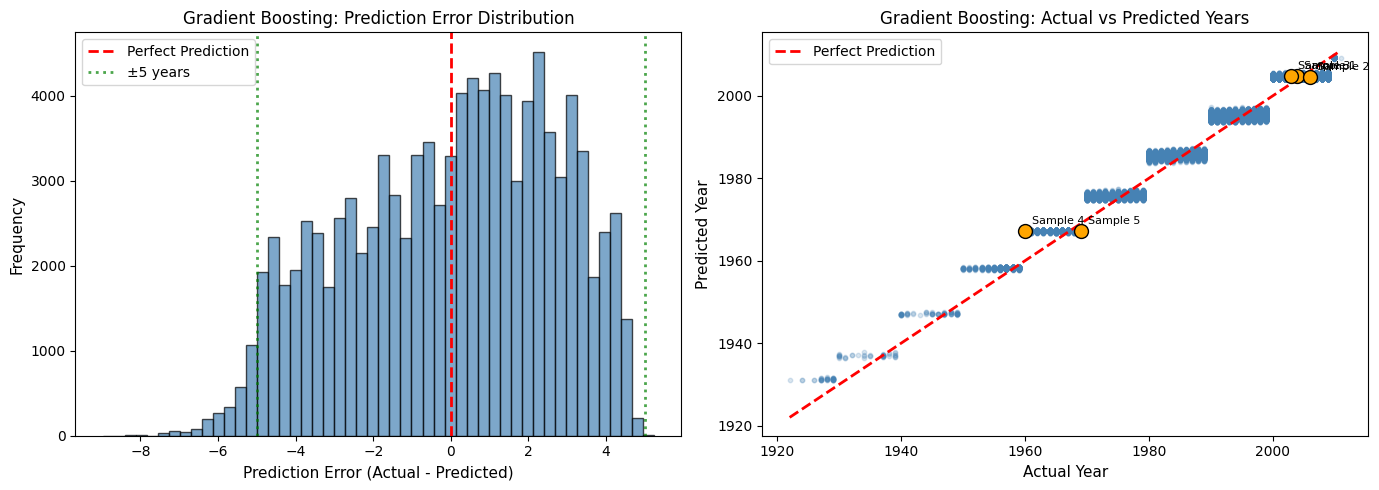

✓ Figure saved: 'part11_predictions.png'

✓ PIPELINE COMPLETED SUCCESSFULLY!


In [18]:
# Get the best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"\n{'─'*50}")
print(f"Using Best Model: {best_model_name}")
print(f"{'─'*50}")

# 11.1 Predict on random samples from test set
print(f"\n{'─'*50}")
print("OUTPUT 11.1: SAMPLE PREDICTIONS (From Test Set)")
print(f"{'─'*50}")

# Select 10 random samples
np.random.seed(123)
sample_indices = np.random.choice(len(y_test_np), size=10, replace=False)

print(f"\n{'Sample':<8} {'Actual Year':<14} {'Predicted Year':<16} {'Error (years)':<14}")
print("─" * 55)

for i, idx in enumerate(sample_indices, 1):
    actual = y_test_np[idx]
    predicted = best_model.predict(X_test_scaled[idx].reshape(1, -1))[0]
    error = actual - predicted
    print(f"{i:<8} {int(actual):<14} {predicted:<16.1f} {error:>+.1f}")

# 11.2 Prediction Statistics
print(f"\n{'─'*50}")
print("OUTPUT 11.2: PREDICTION STATISTICS ON TEST SET")
print(f"{'─'*50}")

all_predictions = best_model.predict(X_test_scaled)
errors = y_test_np - all_predictions

print(f"\n• Total Test Samples: {len(y_test_np):,}")
print(f"• Mean Predicted Year: {all_predictions.mean():.1f}")
print(f"• Mean Actual Year: {y_test_np.mean():.1f}")
print(f"\n• Mean Error: {errors.mean():+.2f} years")
print(f"• Median Error: {np.median(errors):+.2f} years")
print(f"• Std of Errors: {errors.std():.2f} years")
print(f"\n• Predictions within ±5 years: {(np.abs(errors) <= 5).sum()} ({(np.abs(errors) <= 5).mean()*100:.1f}%)")
print(f"• Predictions within ±10 years: {(np.abs(errors) <= 10).sum()} ({(np.abs(errors) <= 10).mean()*100:.1f}%)")

# 11.3 Function to predict new songs
print(f"\n{'─'*50}")
print("OUTPUT 11.3: PREDICTION FUNCTION FOR NEW SONGS")
print(f"{'─'*50}")

def predict_song_year(features, model=best_model, scaler=scaler):
    """
    Predict the release year of a song based on audio features.

    Parameters:
    -----------
    features : array-like
        Audio features of the song (must match training feature count)
    model : trained model
        The regression model to use
    scaler : fitted scaler
        The StandardScaler fitted on training data

    Returns:
    --------
    predicted_year : float
        Predicted release year
    """
    features = np.array(features).reshape(1, -1).astype(np.float32)
    features_scaled = scaler.transform(features)
    predicted_year = model.predict(features_scaled)[0]
    return predicted_year

print("""
Function created: predict_song_year(features)

Usage Example:
─────────────────────────────────────────────────
# Get features for a song (all feature columns)
song_features = [49.94, 21.47, 73.07, ...]  # Your feature values

# Predict the year
predicted_year = predict_song_year(song_features)
print(f"Predicted Release Year: {predicted_year:.0f}")
─────────────────────────────────────────────────
""")

# 11.4 Demo prediction with a test sample
print(f"\n{'─'*50}")
print("OUTPUT 11.4: DEMO PREDICTION")
print(f"{'─'*50}")

# Use first test sample as demo
demo_features = X_test_scaled[0].reshape(1, -1)
demo_actual = y_test_np[0]
demo_predicted = best_model.predict(demo_features)[0]

print(f"\nDemo Song from Test Set:")
print(f"  • Actual Release Year: {int(demo_actual)}")
print(f"  • Predicted Release Year: {demo_predicted:.1f}")
print(f"  • Prediction Error: {demo_actual - demo_predicted:+.1f} years")

# Visualization of predictions
print(f"\n{'─'*50}")
print("OUTPUT 11.5: PREDICTION VISUALIZATION")
print(f"{'─'*50}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Prediction Error Distribution
ax1 = axes[0]
ax1.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=0, color='red', linestyle='--', lw=2, label='Perfect Prediction')
ax1.axvline(x=-5, color='green', linestyle=':', lw=2, alpha=0.7)
ax1.axvline(x=5, color='green', linestyle=':', lw=2, alpha=0.7, label='±5 years')
ax1.set_xlabel('Prediction Error (Actual - Predicted)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title(f'{best_model_name}: Prediction Error Distribution', fontsize=12)
ax1.legend()

# Plot 2: Actual vs Predicted with sample annotations
ax2 = axes[1]
ax2.scatter(y_test_np, all_predictions, alpha=0.2, s=10, c='steelblue')
ax2.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()],
         'r--', lw=2, label='Perfect Prediction')

# Annotate sample predictions
for i, idx in enumerate(sample_indices[:5]):
    ax2.scatter(y_test_np[idx], all_predictions[idx], c='orange', s=100,
                edgecolor='black', zorder=5)
    ax2.annotate(f'Sample {i+1}', (y_test_np[idx], all_predictions[idx]),
                 textcoords="offset points", xytext=(5,5), fontsize=8)

ax2.set_xlabel('Actual Year', fontsize=11)
ax2.set_ylabel('Predicted Year', fontsize=11)
ax2.set_title(f'{best_model_name}: Actual vs Predicted Years', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.savefig('part11_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figure saved: 'part11_predictions.png'")

print("\n" + "="*70)
print("✓ PIPELINE COMPLETED SUCCESSFULLY!")
print("="*70)